# Exploração — `tabela_final.csv` (tabela de features da modelagem)
Uma linha por semana epidemiológica. Junta **vetor** (armadilhas), **clima**, **alvo** (casos) e **ENSO**.
Foco: distribuição das colunas, nulos e cobertura temporal. Direto ao ponto.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 170)
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
ROXO, VERM, VERDE, LARANJA, AZUL = '#6A5391', '#B0574B', '#6E8B5A', '#B07D33', '#3E6B8C'

CSV = 'tabela_final.csv'
df = pd.read_csv(CSV, parse_dates=['data_inicio_semana_epidemi'])
df = df.rename(columns={'data_inicio_semana_epidemi': 'data'})
df.shape

(725, 36)

## 1. Visão geral

In [2]:
print('linhas x colunas :', df.shape)
print('período           :', df['data'].min().date(), '->', df['data'].max().date())
print('anos              :', int(df['ano'].min()), '->', int(df['ano'].max()))
print('fonte             :', df['fonte'].value_counts().to_dict())
print('alvo (casos_confirmados) ausente em', int(df['casos_confirmados'].isna().sum()), 'semanas')

linhas x colunas : (725, 36)
período           : 2012-09-23 -> 2026-08-09
anos              : 2012 -> 2026
fonte             : {'secretaria': 686, 'raspagem': 32}
alvo (casos_confirmados) ausente em 297 semanas


In [3]:
df.dtypes

fonte                                     str
SE                                      int64
data                           datetime64[us]
ano                                     int64
semana                                  int64
numero_de_armadilhas                  float64
aedes_aegypti                         float64
aedes_albopictus                      float64
culex_sp                              float64
aedes_aegypti_por_armadilha           float64
denominador_aproximado                float64
precip_total_mm                       float64
precip_max_dia_mm                     float64
precip_media_dia_mm                   float64
dias_de_chuva                           int64
temp_media                            float64
temp_min                              float64
temp_max                              float64
temp_amplitude_media                  float64
orvalho_min                           float64
orvalho_media                         float64
orvalho_max                       

In [4]:
df.head(4)

,fonte,SE,data,ano,semana,numero_de_armadilhas,aedes_aegypti,aedes_albopictus,culex_sp,aedes_aegypti_por_armadilha,denominador_aproximado,precip_total_mm,precip_max_dia_mm,precip_media_dia_mm,dias_de_chuva,temp_media,temp_min,temp_max,temp_amplitude_media,orvalho_min,orvalho_media,orvalho_max,umid_min,umid_media,umid_max,pressao_min,pressao_media,pressao_max,radiacao_min,radiacao_media,radiacao_max,vento_media,vento_max,casos_confirmados,nino34_anom,oni
0,secretaria,201239,2012-09-23,2012,39,493.0,32.0,4.0,203.0,0.056795,1.0,1.58,0.63,0.225714,0,14.565714,6.26,26.60,11.274286,6.53,9.971429,14.44,70.49,75.741429,81.23,100.91,101.930000,102.54,5.54,17.422857,24.53,4.430000,5.89,NaN,NaN,NaN
1,secretaria,201240,2012-09-30,2012,40,579.0,16.0,6.0,115.0,0.027634,1.0,47.71,19.54,6.815714,5,20.727143,12.93,30.98,9.438571,15.60,18.422857,20.93,80.72,87.500000,92.78,100.62,100.898571,101.27,3.92,12.661429,22.32,2.772857,3.50,NaN,NaN,NaN
2,secretaria,201241,2012-10-07,2012,41,651.0,25.0,17.0,107.0,0.038402,1.0,25.43,17.72,3.632857,5,20.295714,11.36,29.67,8.545714,11.83,16.691429,21.94,72.31,80.772857,87.63,100.43,101.278571,102.03,3.85,13.324286,24.90,4.170000,6.12,NaN,NaN,NaN
3,secretaria,201242,2012-10-14,2012,42,704.0,43.0,6.0,166.0,0.059659,1.0,1.54,1.42,0.220000,1,19.172857,11.26,28.41,11.535714,12.91,14.900000,18.10,74.36,77.952857,81.85,100.34,100.828571,101.52,17.29,22.717143,27.74,3.805714,5.72,NaN,NaN,NaN


## 2. Estatísticas descritivas (numéricas)

In [5]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
SE,725.0,201944.190345,201239.0,201611.0,201936.0,202308.0,202632.0,401.875606
data,725,2019-09-01 00:00:00,2012-09-23 00:00:00,2016-03-13 00:00:00,2019-09-01 00:00:00,2023-02-19 00:00:00,2026-08-09 00:00:00,NaN
ano,725.0,2019.176552,2012.0,2016.0,2019.0,2023.0,2026.0,4.029827
semana,725.0,26.535172,1.0,13.0,26.0,40.0,53.0,15.123084
numero_de_armadilhas,718.0,862.495822,14.0,714.0,860.0,928.0,1436.0,214.878083
aedes_aegypti,718.0,330.710306,0.0,36.25,206.5,529.75,1955.0,353.217887
aedes_albopictus,718.0,7.55571,0.0,0.0,3.0,9.0,120.0,11.603832
culex_sp,718.0,222.399721,0.0,98.0,181.0,297.75,975.0,170.536941
aedes_aegypti_por_armadilha,718.0,0.391134,0.0,0.043606,0.233412,0.621501,2.179888,0.426217
denominador_aproximado,718.0,0.451253,0.0,0.0,0.0,1.0,1.0,0.497965


## 3. Nulos — panorama geral

In [6]:
nul = df.isna().sum()
nul = nul[nul > 0].sort_values(ascending=False)
tab_nul = pd.DataFrame({'nulos': nul, 'pct': (nul / len(df) * 100).round(1)})
tab_nul

,nulos,pct
casos_confirmados,297,41.0
oni,291,40.1
nino34_anom,286,39.4
fonte,7,1.0
numero_de_armadilhas,7,1.0
aedes_aegypti,7,1.0
aedes_albopictus,7,1.0
culex_sp,7,1.0
aedes_aegypti_por_armadilha,7,1.0
denominador_aproximado,7,1.0


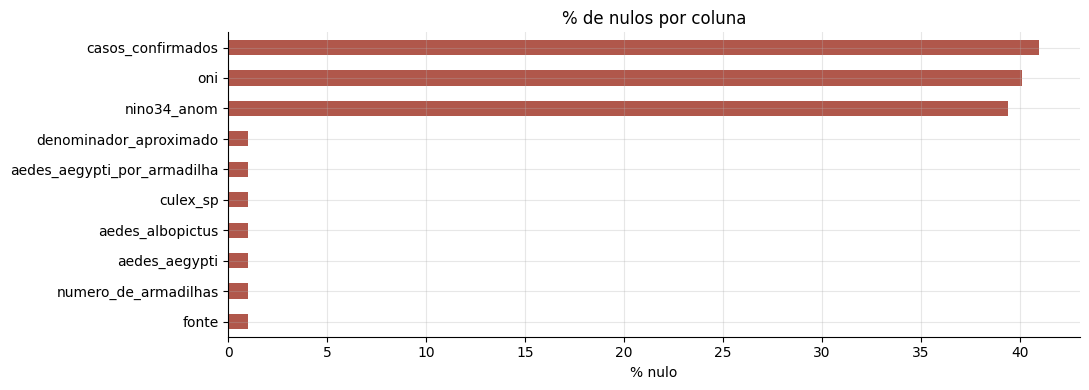

In [7]:
if len(nul):
    ax = tab_nul['pct'].sort_values().plot(kind='barh', color=VERM)
    ax.set_title('% de nulos por coluna'); ax.set_xlabel('% nulo')
    plt.tight_layout(); plt.show()
else:
    print('Sem colunas com nulos.')

## 4. Nulos ao longo do tempo
Onde estão os buracos? (esperado: clima/ENSO/casos não existirem nos anos mais antigos da série da secretaria).

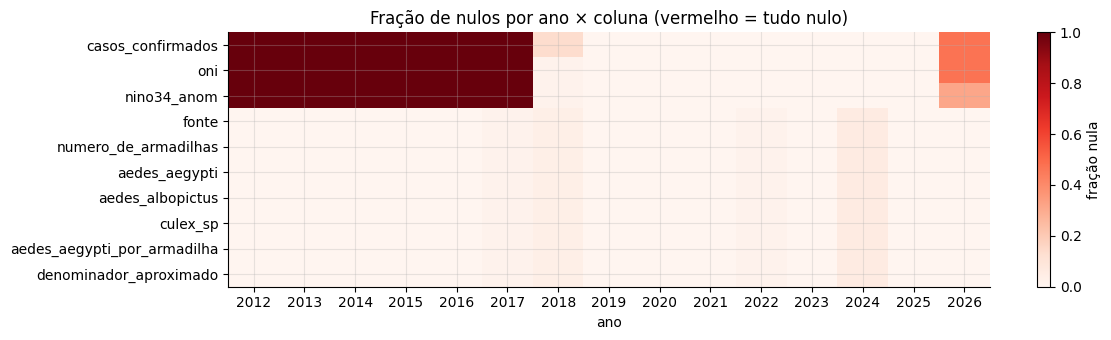

In [8]:
cols_nul = list(nul.index)
if cols_nul:
    frac = df.groupby('ano')[cols_nul].apply(lambda g: g.isna().mean())
    fig, ax = plt.subplots(figsize=(12, max(3, 0.35 * len(cols_nul))))
    im = ax.imshow(frac.T.values, aspect='auto', cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks(range(len(frac.index))); ax.set_xticklabels(frac.index.astype(int), rotation=0)
    ax.set_yticks(range(len(cols_nul))); ax.set_yticklabels(cols_nul)
    ax.set_xlabel('ano'); ax.set_title('Fração de nulos por ano × coluna (vermelho = tudo nulo)')
    fig.colorbar(im, ax=ax, label='fração nula')
    plt.tight_layout(); plt.show()
else:
    print('Sem nulos para mapear.')

In [9]:
# linhas 100% completas vs com algum nulo, por ano
completa = df.notna().all(axis=1)
por_ano = df.assign(completa=completa).groupby('ano')['completa'].agg(['sum', 'count'])
por_ano['pct_completa'] = (por_ano['sum'] / por_ano['count'] * 100).round(1)
por_ano

,sum,count,pct_completa
ano,,,
2012,0,14,0.0
2013,0,52,0.0
2014,0,53,0.0
2015,0,52,0.0
2016,0,52,0.0
2017,0,52,0.0
2018,45,52,86.5
2019,52,52,100.0
2020,53,53,100.0


## 5. Alvo — casos confirmados

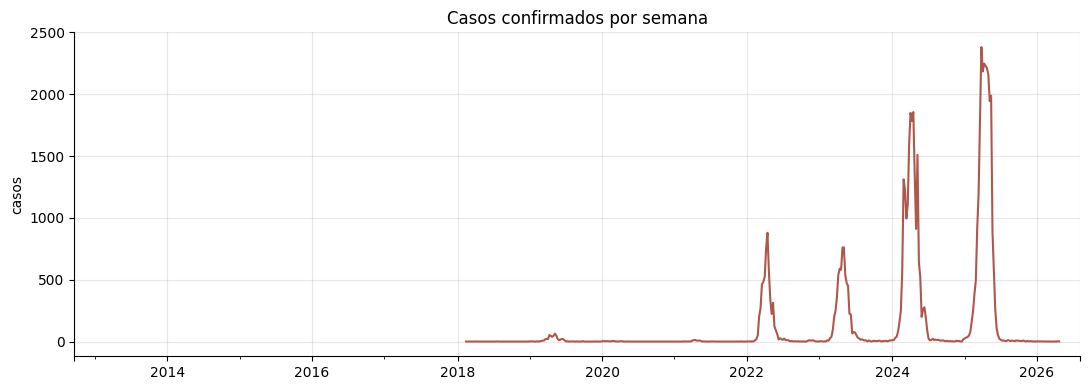

In [10]:
s = df.set_index('data')['casos_confirmados']
ax = s.plot(color=VERM)
ax.set_title('Casos confirmados por semana'); ax.set_xlabel(''); ax.set_ylabel('casos')
plt.tight_layout(); plt.show()

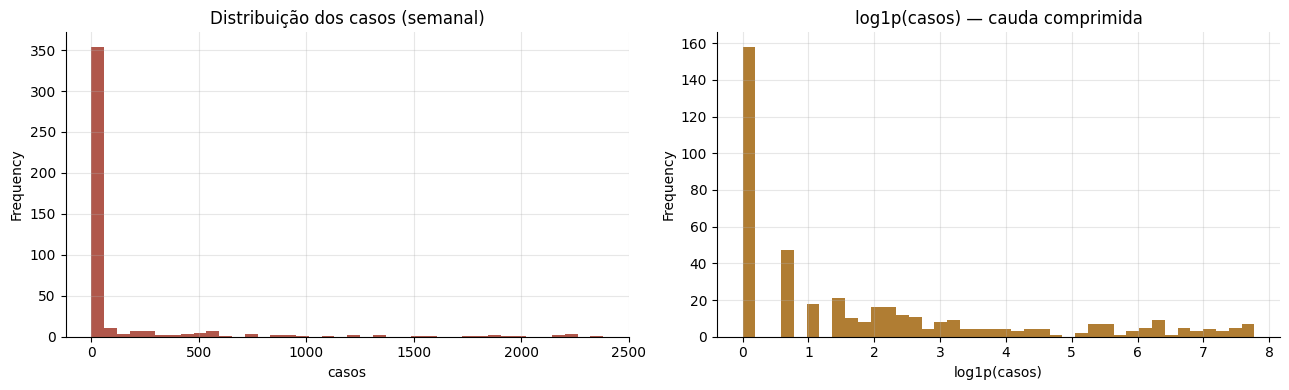

count     428.0
mean      132.3
std       398.4
min         0.0
25%         0.0
50%         2.0
75%        17.2
max      2381.0
Name: casos_confirmados, dtype: float64

In [11]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
df['casos_confirmados'].plot(kind='hist', bins=40, ax=a1, color=VERM)
a1.set_title('Distribuição dos casos (semanal)'); a1.set_xlabel('casos')
np.log1p(df['casos_confirmados']).plot(kind='hist', bins=40, ax=a2, color=LARANJA)
a2.set_title('log1p(casos) — cauda comprimida'); a2.set_xlabel('log1p(casos)')
plt.tight_layout(); plt.show()
df['casos_confirmados'].describe().round(1)

## 6. Vetor — armadilhas e aedes aegypti

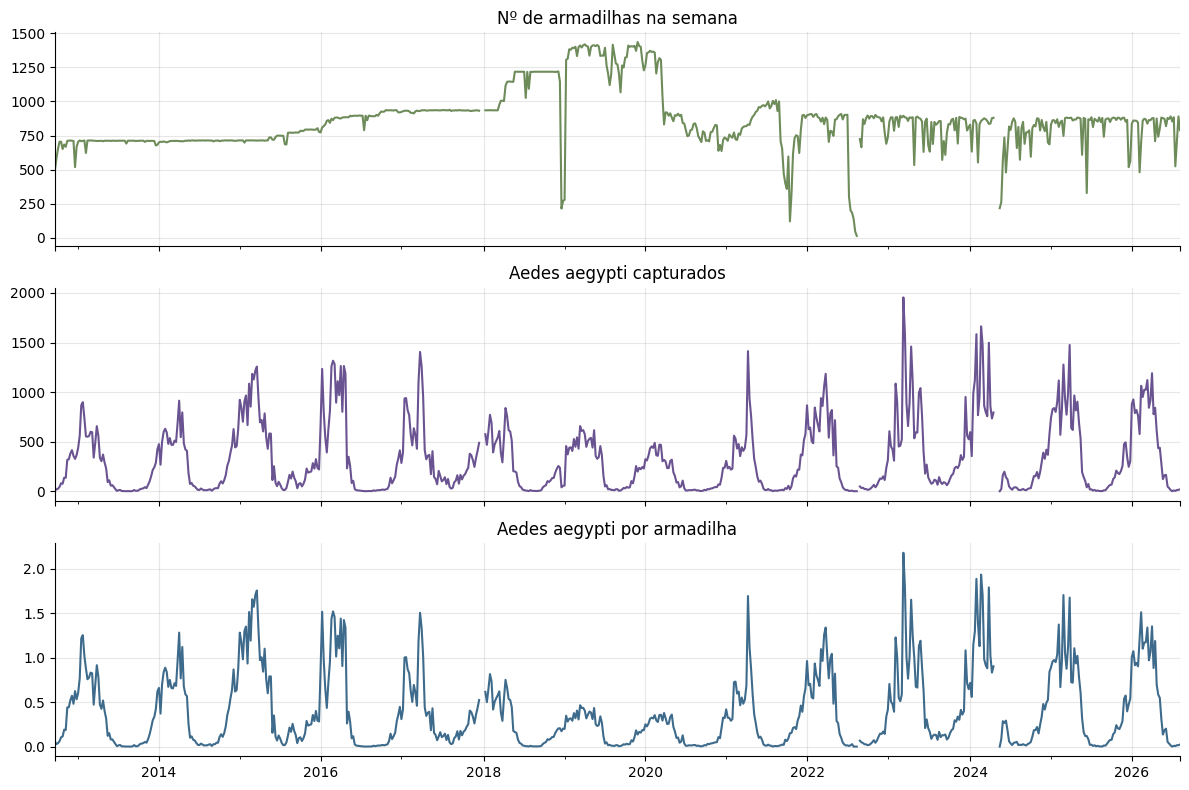

In [12]:
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
df.set_index('data')['numero_de_armadilhas'].plot(ax=axs[0], color=VERDE)
axs[0].set_title('Nº de armadilhas na semana')
df.set_index('data')['aedes_aegypti'].plot(ax=axs[1], color=ROXO)
axs[1].set_title('Aedes aegypti capturados')
df.set_index('data')['aedes_aegypti_por_armadilha'].plot(ax=axs[2], color=AZUL)
axs[2].set_title('Aedes aegypti por armadilha'); axs[2].set_xlabel('')
plt.tight_layout(); plt.show()

## 7. Clima — visão rápida das séries

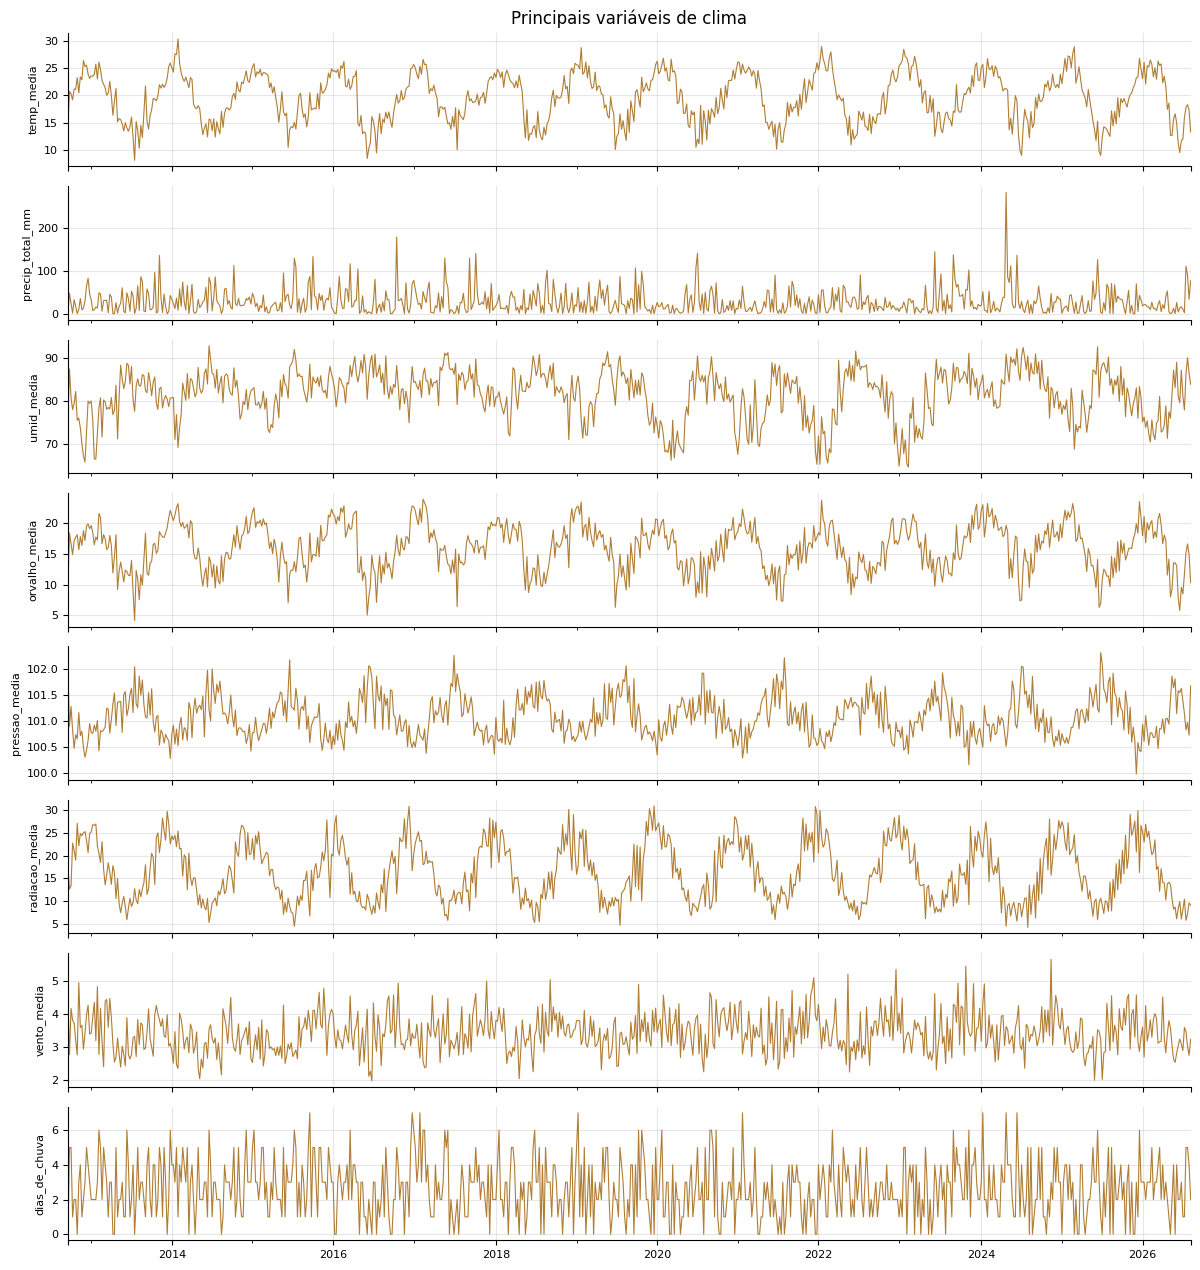

In [13]:
clima = ['temp_media', 'precip_total_mm', 'umid_media', 'orvalho_media',
         'pressao_media', 'radiacao_media', 'vento_media', 'dias_de_chuva']
clima = [c for c in clima if c in df.columns]
fig, axs = plt.subplots(len(clima), 1, figsize=(12, 1.6 * len(clima)), sharex=True)
for ax, c in zip(axs, clima):
    df.set_index('data')[c].plot(ax=ax, color=LARANJA, lw=0.8)
    ax.set_ylabel(c, fontsize=8); ax.tick_params(labelsize=8)
axs[0].set_title('Principais variáveis de clima'); axs[-1].set_xlabel('')
plt.tight_layout(); plt.show()

## 8. ENSO (El Niño / La Niña)

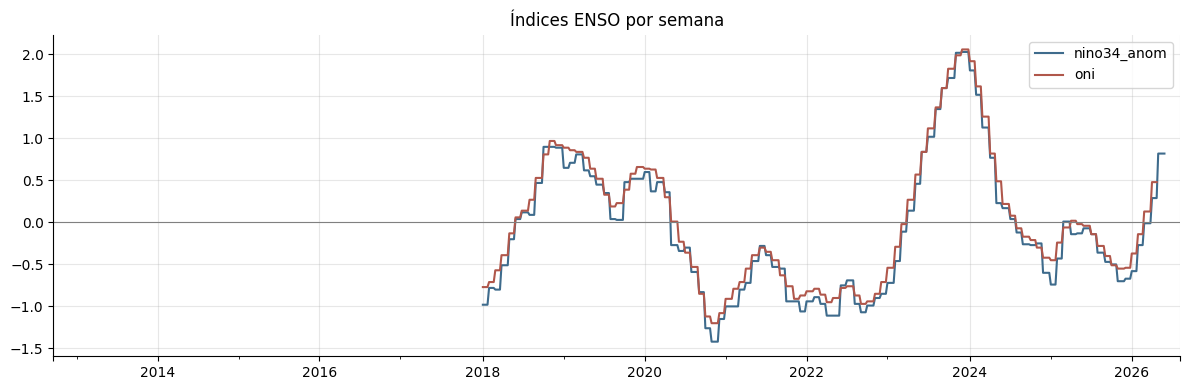

,nino34_anom,oni
count,439.00,434.00
mean,-0.08,0.00
std,0.79,0.77
min,-1.42,-1.20
25%,-0.72,-0.57
50%,-0.25,-0.14
75%,0.47,0.53
max,2.03,2.06


In [14]:
fig, ax = plt.subplots(figsize=(12, 4))
df.set_index('data')[['nino34_anom', 'oni']].plot(ax=ax, color=[AZUL, VERM])
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Índices ENSO por semana'); ax.set_xlabel('')
plt.tight_layout(); plt.show()
df[['nino34_anom', 'oni']].describe().round(2)

## 9. Cobertura temporal — semanas por ano e gaps

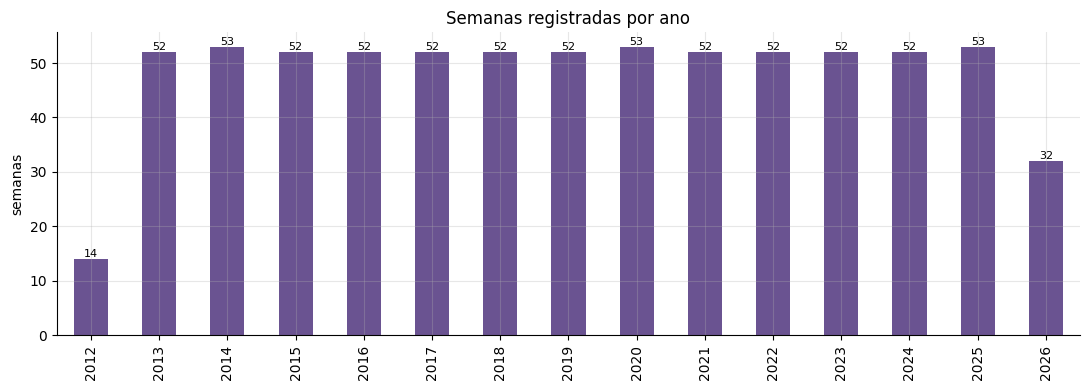

In [15]:
por_ano_n = df.groupby('ano').size()
ax = por_ano_n.plot(kind='bar', color=ROXO)
ax.set_title('Semanas registradas por ano'); ax.set_xlabel(''); ax.set_ylabel('semanas')
for i, v in enumerate(por_ano_n): ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

In [16]:
# gaps: semanas 1..52 faltando por ano (pontas 2012/2026 são parciais e esperadas)
faltantes = {}
for a in range(int(df['ano'].min()), int(df['ano'].max()) + 1):
    tem = set(df.loc[df['ano'] == a, 'semana'].dropna().astype(int))
    falt = sorted(set(range(1, 53)) - tem)
    if falt: faltantes[a] = falt
for a, f in faltantes.items():
    print(f'{a}: {len(f):2d} semanas sem linha -> {f}')

2012: 38 semanas sem linha -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
2026: 20 semanas sem linha -> [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52]


## 10. Correlação

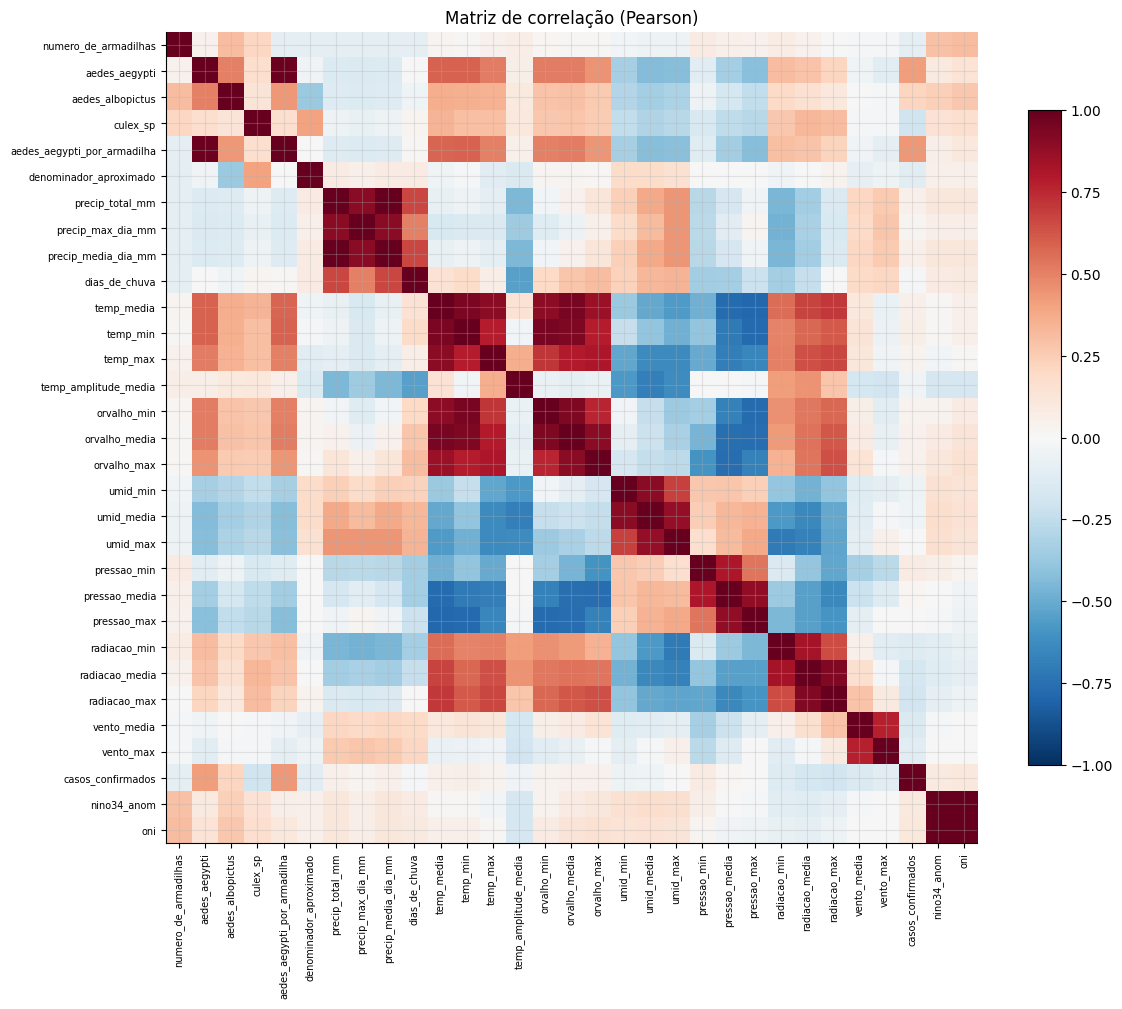

In [17]:
num = df.select_dtypes('number').drop(columns=['ano', 'semana', 'SE'], errors='ignore')
corr = num.corr()
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title('Matriz de correlação (Pearson)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

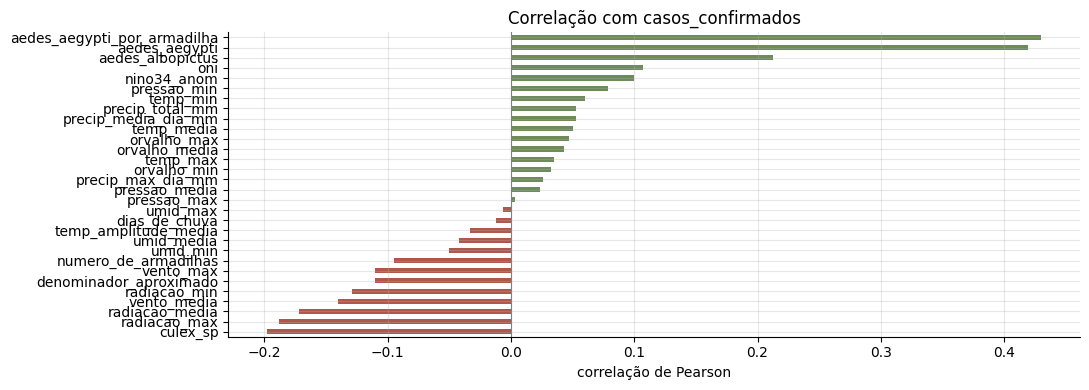

culex_sp                      -0.198
radiacao_max                  -0.188
radiacao_media                -0.172
vento_media                   -0.141
radiacao_min                  -0.129
denominador_aproximado        -0.111
vento_max                     -0.110
numero_de_armadilhas          -0.095
umid_min                      -0.050
umid_media                    -0.042
temp_amplitude_media          -0.033
dias_de_chuva                 -0.012
umid_max                      -0.006
pressao_max                    0.003
pressao_media                  0.023
precip_max_dia_mm              0.026
orvalho_min                    0.032
temp_max                       0.035
orvalho_media                  0.043
orvalho_max                    0.047
temp_media                     0.050
precip_media_dia_mm            0.053
precip_total_mm                0.053
temp_min                       0.060
pressao_min                    0.079
nino34_anom                    0.100
oni                            0.107
a

In [18]:
# correlação de cada variável com o alvo
alvo = 'casos_confirmados'
c = num.corr()[alvo].drop(alvo).sort_values()
ax = c.plot(kind='barh', color=[VERM if v < 0 else VERDE for v in c])
ax.set_title(f'Correlação com {alvo}'); ax.set_xlabel('correlação de Pearson')
ax.axvline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.show()
c.round(3)